# Supplementary analysis for the scaffold-tuner benchmark

This notebook generates the tables and figures intended for the **Supplementary Materials** of the scaffold-tuner manuscript.

The analyses are deliberately separated from the main-text figures. They provide numerical detail, statistical support, and sensitivity analyses for the principal conclusions:

1. candidate-generation coverage and applicability;
2. numerical values underlying the limited-candidate-budget analysis;
3. parent-level changes in QED and SA Score, including paired statistical comparisons;
4. task-wise structural locality of successful edits in the common REINVENT4-applicable subset;
5. descriptor selectivity and collateral descriptor changes;
6. sensitivity of task success rates to the denominator (all 1,000 parents vs. the common REINVENT4-applicable subset).

All task-specific analyses of scaffold-tuner use only the mode corresponding to the requested descriptor change.

## Preparation

In [1]:
from pathlib import Path
import os
import sys
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, wilcoxon

import rdkit
from rdkit import Chem, DataStructs, RDConfig
from rdkit.Chem import QED
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# RDKit SA Score implementation
sa_score_dir = os.path.join(RDConfig.RDContribDir, "SA_Score")
if sa_score_dir not in sys.path:
    sys.path.append(sa_score_dir)
import sascorer

SEED = 42
N_PARENTS = 1000
N_CANDIDATES_PER_PARENT = 100

print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}, RDKit: {rdkit.__version__}")

NumPy: 2.4.6, Pandas: 3.0.5, RDKit: 2026.03.5


In [2]:
RESULTS_DIR = Path("../results")
SUPP_DIR = RESULTS_DIR / "supplementary"
SUPP_FIG_DIR = SUPP_DIR / "figures"
SUPP_DIR.mkdir(exist_ok=True)
SUPP_FIG_DIR.mkdir(exist_ok=True)

METHOD_ORDER = [
    "scaffold-tuner",
    "Random local editing",
    "CReM",
    "REINVENT4 Mol2Mol",
]

METHOD_FILES = {
    "scaffold-tuner": RESULTS_DIR / "scaffold_tuner.csv",
    "Random local editing": RESULTS_DIR / "random_local_editing.csv",
    "CReM": RESULTS_DIR / "crem.csv",
    "REINVENT4 Mol2Mol": RESULTS_DIR / "reinvent4_mol2mol.csv",
}

PARENT_FILE = Path("../data/chembl_1000_parents.csv")
REINVENT_UNSUPPORTED_FILE = RESULTS_DIR / "reinvent4_unsupported_parents.csv"

TARGETS = {
    "HBD": "delta_hbd",
    "HBA": "delta_hba",
    "RotB": "delta_rotb",
    "Aromatic rings": "delta_ar",
}
DELTA_COLS = list(TARGETS.values())

TASK_ORDER = [
    "HBD increase", "HBD decrease",
    "HBA increase", "HBA decrease",
    "RotB increase", "RotB decrease",
    "Aromatic rings increase", "Aromatic rings decrease",
]

SCAFFOLD_MODE_BY_TASK = {
    ("HBD", "increase"): "add_hbd",
    ("HBD", "decrease"): "remove_hbd",
    ("HBA", "increase"): "add_hba",
    ("HBA", "decrease"): "remove_hba",
    ("RotB", "increase"): "add_rb",
    ("RotB", "decrease"): "remove_rb",
    ("Aromatic rings", "increase"): "add_ar",
    ("Aromatic rings", "decrease"): "remove_ar",
}

In [3]:
parents = pd.read_csv(PARENT_FILE)[["chembl_id", "smiles"]].drop_duplicates("chembl_id")
assert len(parents) == N_PARENTS

results = {name: pd.read_csv(path) for name, path in METHOD_FILES.items()}

required_cols = {
    "chembl_id", "parent_smiles", "generated_smiles",
    "delta_hbd", "delta_hba", "delta_ar", "delta_rotb",
}
for name, df in results.items():
    missing = required_cols - set(df.columns)
    assert not missing, f"{name}: missing columns {missing}"

unsupported_reinvent = set()
if REINVENT_UNSUPPORTED_FILE.exists():
    tmp = pd.read_csv(REINVENT_UNSUPPORTED_FILE)
    if "chembl_id" in tmp.columns:
        unsupported_reinvent = set(tmp["chembl_id"].dropna())
    else:
        smiles_col = next((c for c in ["parent_smiles", "smiles"] if c in tmp.columns), None)
        if smiles_col is not None:
            unsupported_smiles = set(tmp[smiles_col].dropna())
            unsupported_reinvent = set(
                parents.loc[parents["smiles"].isin(unsupported_smiles), "chembl_id"]
            )

common_parent_ids = pd.Index(
    parents.loc[~parents["chembl_id"].isin(unsupported_reinvent), "chembl_id"]
)

common_results = {
    name: df[df["chembl_id"].isin(common_parent_ids)].copy()
    for name, df in results.items()
}


print({name: df.shape for name, df in results.items()})
print(f"Common REINVENT4-applicable subset: {len(common_parent_ids)} / {N_PARENTS}")

{'scaffold-tuner': (34499, 16), 'Random local editing': (30248, 15), 'CReM': (24992, 15), 'REINVENT4 Mol2Mol': (61388, 15)}
Common REINVENT4-applicable subset: 929 / 1000


### Shared helper functions

In [4]:
def task_specific_df(method, df, target, direction):
    if method != "scaffold-tuner":
        return df
    if "mode" not in df.columns:
        raise ValueError("scaffold_tuner.csv must contain a 'mode' column.")
    mode = SCAFFOLD_MODE_BY_TASK[(target, direction)]
    return df[df["mode"] == mode].copy()


def success_table(results_dict, denominator_parent_ids):
    denominator_parent_ids = pd.Index(denominator_parent_ids)
    rows = []
    for method in METHOD_ORDER:
        df_all = results_dict[method]
        for target, delta_col in TARGETS.items():
            other_cols = [c for c in DELTA_COLS if c != delta_col]
            for direction, sign in [("increase", 1), ("decrease", -1)]:
                df = task_specific_df(method, df_all, target, direction)
                exact = df[delta_col].eq(sign)
                selective = exact & df[other_cols].eq(0).all(axis=1)

                parent_exact = (
                    df.loc[exact, "chembl_id"].value_counts()
                    .reindex(denominator_parent_ids, fill_value=0).gt(0)
                )
                parent_selective = (
                    df.loc[selective, "chembl_id"].value_counts()
                    .reindex(denominator_parent_ids, fill_value=0).gt(0)
                )

                rows.append({
                    "method": method,
                    "target": target,
                    "direction": direction,
                    "task": f"{target} {direction}",
                    "n_candidates_in_task_pool": len(df),
                    "parent_success_percent": 100 * parent_exact.mean(),
                    "selective_parent_success_percent": 100 * parent_selective.mean(),
                    "candidate_exact_success_percent": 100 * exact.mean() if len(df) else np.nan,
                })
    return pd.DataFrame(rows)


morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def murcko_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold, canonical=True)


def editing_quality(df):
    parent_cache = {}
    rows = []

    for _, r in df.iterrows():
        psmiles = str(r["parent_smiles"])
        gsmiles = str(r["generated_smiles"])

        if psmiles not in parent_cache:
            pmol = Chem.MolFromSmiles(psmiles)
            parent_cache[psmiles] = {
                "mol": pmol,
                "fp": morgan.GetFingerprint(pmol) if pmol is not None else None,
                "scaffold": murcko_smiles(pmol) if pmol is not None else None,
                "qed": QED.qed(pmol) if pmol is not None else np.nan,
                "sa": sascorer.calculateScore(pmol) if pmol is not None else np.nan,
            }

        p = parent_cache[psmiles]
        gmol = Chem.MolFromSmiles(gsmiles)
        valid = gmol is not None and p["mol"] is not None

        rec = r.to_dict()
        rec["valid_generated_smiles"] = valid

        if not valid:
            rec.update({
                "tanimoto_to_parent": np.nan,
                "murcko_retained": False,
                "qed_parent": p["qed"], "qed": np.nan, "delta_qed": np.nan,
                "sa_score_parent": p["sa"], "sa_score": np.nan, "delta_sa_score": np.nan,
            })
        else:
            gfp = morgan.GetFingerprint(gmol)
            gqed = QED.qed(gmol)
            gsa = sascorer.calculateScore(gmol)
            rec.update({
                "tanimoto_to_parent": DataStructs.TanimotoSimilarity(p["fp"], gfp),
                "murcko_retained": p["scaffold"] == murcko_smiles(gmol),
                "qed_parent": p["qed"], "qed": gqed, "delta_qed": gqed - p["qed"],
                "sa_score_parent": p["sa"], "sa_score": gsa, "delta_sa_score": gsa - p["sa"],
            })
        rows.append(rec)

    return pd.DataFrame(rows)


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        value = min(1.0, (m - rank) * p[idx])
        running = max(running, value)
        adjusted[idx] = running
    return adjusted

## Supplementary Table S1. Candidate-generation and applicability summary

For scaffold-tuner, the generation unit is **parent × directed mode/task**. For the other methods, the generation unit is the parent molecule. This distinction avoids pooling the eight separate scaffold-tuner mode calls into one artificially large parent-level candidate count.

In [5]:
rows = []

for method in METHOD_ORDER:
    df = results[method]

    if method == "scaffold-tuner":
        modes = list(SCAFFOLD_MODE_BY_TASK.values())
        full_index = pd.MultiIndex.from_product(
            [parents["chembl_id"], modes], names=["chembl_id", "mode"]
        )
        counts = df.groupby(["chembl_id", "mode"]).size().reindex(full_index, fill_value=0)
        generation_unit = "parent × task"
        expected_units = len(full_index)
    else:
        counts = df.groupby("chembl_id").size().reindex(parents["chembl_id"], fill_value=0)
        generation_unit = "parent"
        expected_units = N_PARENTS

    rows.append({
        "method": method,
        "generation_unit": generation_unit,
        "total_retained_candidates": len(df),
        "units_with_candidates": int((counts > 0).sum()),
        "expected_units": expected_units,
        "mean_candidates_per_unit": counts.mean(),
        "median_candidates_per_unit": counts.median(),
        "min_candidates_per_unit": counts.min(),
        "max_candidates_per_unit": counts.max(),
    })

candidate_summary = pd.DataFrame(rows)

# Applicability of parent molecules
app_rows = []
for method in METHOD_ORDER:
    if method == "REINVENT4 Mol2Mol":
        applicable = N_PARENTS - len(unsupported_reinvent)
    else:
        applicable = N_PARENTS
    app_rows.append({
        "method": method,
        "applicable_parents": applicable,
        "applicability_percent": 100 * applicable / N_PARENTS,
    })

applicability_summary = pd.DataFrame(app_rows)

table_s1 = candidate_summary.merge(applicability_summary, on="method")
display(table_s1.round(3))

table_s1.to_csv(SUPP_DIR / "Table_S1_candidate_generation_and_applicability.csv", index=False)

,method,generation_unit,total_retained_candidates,units_with_candidates,expected_units,mean_candidates_per_unit,median_candidates_per_unit,min_candidates_per_unit,max_candidates_per_unit,applicable_parents,applicability_percent
0,scaffold-tuner,parent × task,34499,4628,8000,4.312,5.0,0,30,1000,100.0
1,Random local editing,parent,30248,1000,1000,30.248,30.0,11,50,1000,100.0
2,CReM,parent,24992,860,1000,24.992,20.5,0,100,1000,100.0
3,REINVENT4 Mol2Mol,parent,61388,929,1000,61.388,65.0,0,97,929,92.9


## Supplementary Table S2. Numerical values underlying the limited-candidate-budget analysis

The main figure summarizes the mean parent success rate across eight descriptor-modification tasks for candidate budgets of 1, 5, 10, 20, 50, and 100. The same random-sampling procedure is repeated 20 times; this table reports the mean and SD used in the figure.

In [6]:
K_VALUES = [1, 5, 10, 20, 50, 100]
N_REPEATS = 20

efficiency_rows = []
for repeat in range(N_REPEATS):
    rng_seed = SEED + repeat
    for method in METHOD_ORDER:
        df_all = common_results[method]
        for target, delta_col in TARGETS.items():
            for direction, sign in [("increase", 1), ("decrease", -1)]:
                df_task = task_specific_df(method, df_all, target, direction)
                shuffled = df_task.sample(frac=1, random_state=rng_seed).copy()
                for k in K_VALUES:
                    sampled = shuffled.groupby("chembl_id", group_keys=False).head(k)
                    successful = (
                        sampled.loc[sampled[delta_col].eq(sign), "chembl_id"]
                        .value_counts().reindex(common_parent_ids, fill_value=0).gt(0)
                    )
                    efficiency_rows.append({
                        "repeat": repeat,
                        "method": method,
                        "k": k,
                        "target": target,
                        "direction": direction,
                        "parent_success_percent": 100 * successful.mean(),
                    })

efficiency = pd.DataFrame(efficiency_rows)

efficiency_overall = (
    efficiency.groupby(["repeat", "method", "k"], as_index=False)["parent_success_percent"].mean()
    .groupby(["method", "k"], as_index=False)
    .agg(
        mean_parent_success_percent=("parent_success_percent", "mean"),
        sd_parent_success_percent=("parent_success_percent", "std"),
    )
)

efficiency_overall["mean ± SD (%)"] = efficiency_overall.apply(
    lambda r: f"{r['mean_parent_success_percent']:.2f} ± {r['sd_parent_success_percent']:.2f}",
    axis=1,
)

display(efficiency_overall)
efficiency_overall.to_csv(SUPP_DIR / "Table_S2_candidate_budget_success.csv", index=False)

,method,k,mean_parent_success_percent,sd_parent_success_percent,mean ± SD (%)
0,CReM,1,15.594053,0.364681,15.59 ± 0.36
1,CReM,5,34.015070,0.255558,34.02 ± 0.26
2,CReM,10,38.437164,0.258349,38.44 ± 0.26
3,CReM,20,40.800592,0.174133,40.80 ± 0.17
4,CReM,50,42.393703,0.056768,42.39 ± 0.06
5,CReM,100,42.599569,0.000000,42.60 ± 0.00
6,REINVENT4 Mol2Mol,1,17.146798,0.378195,17.15 ± 0.38
7,REINVENT4 Mol2Mol,5,50.023547,0.345477,50.02 ± 0.35
8,REINVENT4 Mol2Mol,10,65.020183,0.308226,65.02 ± 0.31
9,REINVENT4 Mol2Mol,20,75.926399,0.285907,75.93 ± 0.29


## Supplementary Tables S3a/S3b and Figures S1/S2. QED and SA Score

To avoid pseudoreplication, candidate-level values are reduced to one value per parent and method: the **median ΔQED** and **median ΔSA Score** among retained candidates from that parent. Statistical comparisons use only parents with complete values for all four methods.

A Friedman test is used as the omnibus paired non-parametric comparison. If the omnibus test is significant, pairwise Wilcoxon signed-rank tests are reported with Holm adjustment for multiple comparisons.

For SA Score, positive ΔSA indicates a higher (less favorable) SA Score relative to the parent, whereas negative values indicate a lower (more favorable) score.

In [7]:
# Calculate candidate-level structural/QED/SA metrics once per method.
quality_results = {method: editing_quality(df) for method, df in results.items()}

parent_level_rows = []
for method in METHOD_ORDER:
    q = quality_results[method]
    parent_level = (
        q.groupby("chembl_id", as_index=False)
        .agg(
            median_delta_qed=("delta_qed", "median"),
            median_delta_sa=("delta_sa_score", "median"),
        )
    )
    parent_level["method"] = method
    parent_level_rows.append(parent_level)

qed_sa_parent = pd.concat(parent_level_rows, ignore_index=True)

# Descriptive statistics
s3a_rows = []
for method in METHOD_ORDER:
    part = qed_sa_parent[qed_sa_parent["method"] == method]
    s3a_rows.append({
        "method": method,
        "n_parents": len(part),
        "median_delta_QED": part["median_delta_qed"].median(),
        "mean_delta_QED": part["median_delta_qed"].mean(),
        "SD_delta_QED": part["median_delta_qed"].std(),
        "median_delta_SA": part["median_delta_sa"].median(),
        "mean_delta_SA": part["median_delta_sa"].mean(),
        "SD_delta_SA": part["median_delta_sa"].std(),
    })

table_s3a = pd.DataFrame(s3a_rows)
display(table_s3a.round(4))
table_s3a.to_csv(SUPP_DIR / "Table_S3a_QED_SA_descriptive_statistics.csv", index=False)

,method,n_parents,median_delta_QED,mean_delta_QED,SD_delta_QED,median_delta_SA,mean_delta_SA,SD_delta_SA
0,scaffold-tuner,818,-0.0608,-0.0393,0.0935,0.1098,0.1088,0.1942
1,Random local editing,1000,-0.0262,-0.0309,0.0327,0.2684,0.2957,0.1230
2,CReM,860,-0.0217,-0.0078,0.0644,0.0730,0.0537,0.1297
3,REINVENT4 Mol2Mol,929,0.0001,0.0112,0.0843,0.0066,-0.0099,0.2141


In [8]:
def run_friedman_wilcoxon(parent_df, value_col, metric_name):
    wide = parent_df.pivot(index="chembl_id", columns="method", values=value_col)
    complete = wide[METHOD_ORDER].dropna()

    stat, p = friedmanchisquare(*[complete[m].values for m in METHOD_ORDER])
    omnibus = pd.DataFrame([{
        "metric": metric_name,
        "n_complete_parents": len(complete),
        "friedman_statistic": stat,
        "friedman_p": p,
    }])

    pair_rows = []
    raw_p = []
    for a, b in combinations(METHOD_ORDER, 2):
        try:
            w_stat, w_p = wilcoxon(
                complete[a], complete[b],
                alternative="two-sided",
                zero_method="wilcox",
            )
        except ValueError:
            w_stat, w_p = np.nan, 1.0
        pair_rows.append({
            "metric": metric_name,
            "method_1": a,
            "method_2": b,
            "wilcoxon_statistic": w_stat,
            "raw_p": w_p,
        })
        raw_p.append(w_p)

    pairwise = pd.DataFrame(pair_rows)
    pairwise["holm_adjusted_p"] = holm_adjust(raw_p)
    pairwise["significant_after_holm"] = pairwise["holm_adjusted_p"] < 0.05
    return omnibus, pairwise, complete

qed_omnibus, qed_pairwise, wide_qed = run_friedman_wilcoxon(
    qed_sa_parent, "median_delta_qed", "Delta QED"
)
sa_omnibus, sa_pairwise, wide_sa = run_friedman_wilcoxon(
    qed_sa_parent, "median_delta_sa", "Delta SA Score"
)

table_s3b_omnibus = pd.concat([qed_omnibus, sa_omnibus], ignore_index=True)
table_s3b_pairwise = pd.concat([qed_pairwise, sa_pairwise], ignore_index=True)

display(table_s3b_omnibus)
display(table_s3b_pairwise)

table_s3b_omnibus.to_csv(SUPP_DIR / "Table_S3b_QED_SA_Friedman_tests.csv", index=False)
table_s3b_pairwise.to_csv(SUPP_DIR / "Table_S3c_QED_SA_Wilcoxon_Holm.csv", index=False)

,metric,n_complete_parents,friedman_statistic,friedman_p
0,Delta QED,678,384.096960,6.161575e-83
1,Delta SA Score,678,1151.902626,1.997779e-249


,metric,method_1,method_2,wilcoxon_statistic,raw_p,holm_adjusted_p,significant_after_holm
0,Delta QED,scaffold-tuner,Random local editing,72693.0,9.562205e-17,1.912441e-16,True
1,Delta QED,scaffold-tuner,CReM,38526.0,1.091961e-50,5.459803e-50,True
2,Delta QED,scaffold-tuner,REINVENT4 Mol2Mol,38411.0,7.772174e-51,4.663305e-50,True
3,Delta QED,Random local editing,CReM,66448.0,2.339983e-21,7.019948e-21,True
4,Delta QED,Random local editing,REINVENT4 Mol2Mol,53422.0,1.232696e-33,4.930785e-33,True
5,Delta QED,CReM,REINVENT4 Mol2Mol,87098.0,5.565900e-08,5.565900e-08,True
6,Delta SA Score,scaffold-tuner,Random local editing,18991.0,3.833267e-79,1.533307e-78,True
7,Delta SA Score,scaffold-tuner,CReM,69350.0,7.200731e-19,7.200731e-19,True
8,Delta SA Score,scaffold-tuner,REINVENT4 Mol2Mol,41437.0,3.053157e-47,9.159470e-47,True
9,Delta SA Score,Random local editing,CReM,0.0,1.114405e-112,6.686431e-112,True


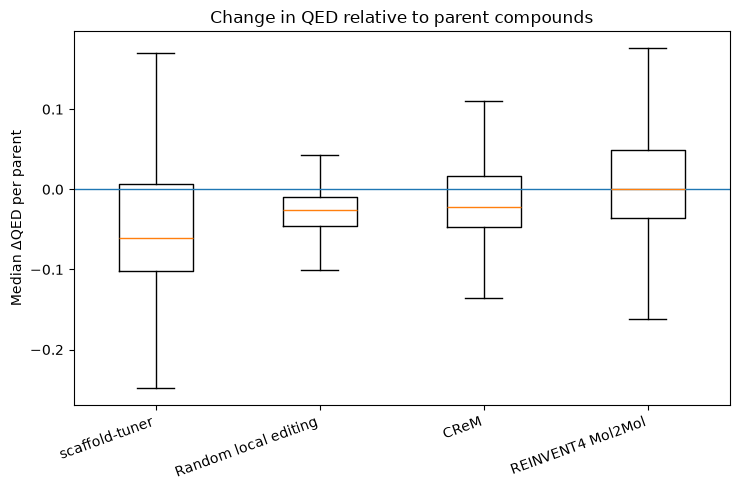

In [9]:
# Supplementary Figure S1: parent-level ΔQED
plot_data = [
    qed_sa_parent.loc[qed_sa_parent["method"] == method, "median_delta_qed"].dropna().values
    for method in METHOD_ORDER
]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.boxplot(plot_data, tick_labels=METHOD_ORDER, showfliers=False)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Median ΔQED per parent")
ax.set_title("Change in QED relative to parent compounds")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(SUPP_FIG_DIR / "Figure_S1_delta_QED.png", dpi=300, bbox_inches="tight")
plt.show()

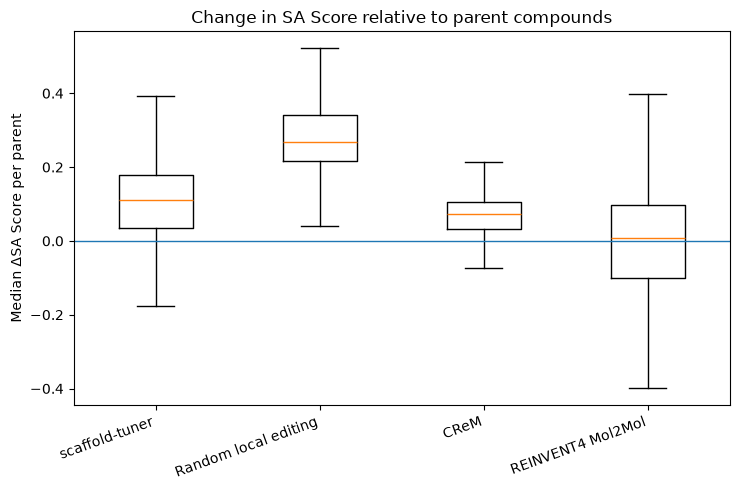

In [10]:
# Supplementary Figure S2: parent-level ΔSA Score
plot_data = [
    qed_sa_parent.loc[qed_sa_parent["method"] == method, "median_delta_sa"].dropna().values
    for method in METHOD_ORDER
]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.boxplot(plot_data, tick_labels=METHOD_ORDER, showfliers=False)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Median ΔSA Score per parent")
ax.set_title("Change in SA Score relative to parent compounds")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(SUPP_FIG_DIR / "Figure_S2_delta_SA.png", dpi=300, bbox_inches="tight")
plt.show()

## Supplementary Table S4. Task-wise locality among successful edits

Only candidates from the common REINVENT4-applicable parent subset that achieved the exact requested descriptor change (Δ = +1 or −1) are included. The table reports median Tanimoto similarity to the parent and Murcko scaffold retention separately for every task and method.


In [11]:
locality_rows = []
for method in METHOD_ORDER:
    q_all = quality_results[method]
    q_all = q_all[q_all["chembl_id"].isin(common_parent_ids)].copy()
    for target, delta_col in TARGETS.items():
        for direction, sign in [("increase", 1), ("decrease", -1)]:
            q = task_specific_df(method, q_all, target, direction)
            success = q[q[delta_col].eq(sign)].copy()
            locality_rows.append({
                "method": method,
                "target": target,
                "direction": direction,
                "task": f"{target} {direction}",
                "n_successful_candidates": len(success),
                "median_similarity": success["tanimoto_to_parent"].median(),
                "murcko_retention_percent": 100 * success["murcko_retained"].mean() if len(success) else np.nan,
            })

table_s4 = pd.DataFrame(locality_rows)
display(table_s4)
table_s4.to_csv(SUPP_DIR / "Table_S4_successful_edit_locality.csv", index=False)

,method,target,direction,task,n_successful_candidates,median_similarity,murcko_retention_percent
0,scaffold-tuner,HBD,increase,HBD increase,5245,0.725000,59.923737
1,scaffold-tuner,HBD,decrease,HBD decrease,3225,0.735849,99.937984
2,scaffold-tuner,HBA,increase,HBA increase,4182,0.750000,99.880440
3,scaffold-tuner,HBA,decrease,HBA decrease,4550,0.742857,79.868132
4,scaffold-tuner,RotB,increase,RotB increase,153,0.672727,100.000000
5,scaffold-tuner,RotB,decrease,RotB decrease,1855,0.722222,83.450135
6,scaffold-tuner,Aromatic rings,increase,Aromatic rings increase,4196,0.696429,0.000000
7,scaffold-tuner,Aromatic rings,decrease,Aromatic rings decrease,0,NaN,NaN
8,Random local editing,HBD,increase,HBD increase,9437,0.727273,88.725230
9,Random local editing,HBD,decrease,HBD decrease,2626,0.714286,86.785986


## Supplementary Table S5. Descriptor selectivity and collateral changes

This table separates two questions: whether a parent has at least one **fully selective** successful candidate, and how much the three non-target benchmark descriptors change among exact-success candidates.

In [12]:
success_common = success_table(common_results, common_parent_ids)

collateral_rows = []
for method in METHOD_ORDER:
    df_all = common_results[method]
    for target, delta_col in TARGETS.items():
        other_cols = [c for c in DELTA_COLS if c != delta_col]
        for direction, sign in [("increase", 1), ("decrease", -1)]:
            df = task_specific_df(method, df_all, target, direction)
            success = df[df[delta_col].eq(sign)].copy()
            if len(success):
                score = success[other_cols].abs().sum(axis=1)
                zero_pct = 100 * (score == 0).mean()
                median_score = score.median()
            else:
                zero_pct = np.nan
                median_score = np.nan

            collateral_rows.append({
                "method": method,
                "target": target,
                "direction": direction,
                "task": f"{target} {direction}",
                "n_successful_candidates": len(success),
                "zero_collateral_candidate_percent": zero_pct,
                "median_collateral_change_score": median_score,
            })

collateral_summary = pd.DataFrame(collateral_rows)

table_s5 = success_common.merge(
    collateral_summary,
    on=["method", "target", "direction", "task"],
    how="left",
)

table_s5 = table_s5[[
    "method", "task", "n_candidates_in_task_pool",
    "parent_success_percent", "selective_parent_success_percent",
    "candidate_exact_success_percent", "n_successful_candidates",
    "zero_collateral_candidate_percent", "median_collateral_change_score",
]]

display(table_s5)
table_s5.to_csv(SUPP_DIR / "Table_S5_selectivity_and_collateral_changes.csv", index=False)

,method,task,n_candidates_in_task_pool,parent_success_percent,selective_parent_success_percent,candidate_exact_success_percent,n_successful_candidates,zero_collateral_candidate_percent,median_collateral_change_score
0,scaffold-tuner,HBD increase,5245,69.752422,1.184069,100.000000,5245,0.686368,3.0
1,scaffold-tuner,HBD decrease,3765,48.977395,0.430571,85.657371,3225,0.465116,2.0
2,scaffold-tuner,HBA increase,5231,69.752422,15.177610,79.946473,4182,3.873745,2.0
3,scaffold-tuner,HBA decrease,5850,59.849300,19.806243,77.777778,4550,6.571429,1.0
4,scaffold-tuner,RotB increase,5242,15.177610,15.177610,2.918733,153,96.078431,0.0
5,scaffold-tuner,RotB decrease,3256,51.345533,8.180840,56.971744,1855,11.212938,2.0
6,scaffold-tuner,Aromatic rings increase,4196,69.752422,0.322928,100.000000,4196,0.071497,3.0
7,scaffold-tuner,Aromatic rings decrease,0,0.000000,0.000000,NaN,0,NaN,NaN
8,Random local editing,HBD increase,28061,100.000000,59.095802,33.630305,9437,9.219031,1.0
9,Random local editing,HBD decrease,28061,73.304629,43.595264,9.358184,2626,35.148515,1.0


## Supplementary Table S6. Sensitivity analysis: all 1,000 parents vs. common 929-parent subset

REINVENT4 Mol2Mol was not applicable to all parent SMILES. The main cross-method comparison therefore uses the common REINVENT4-applicable subset. This sensitivity table shows how the task-level parent success rates change when all 1,000 parents are used as the denominator.

In [13]:
success_all_1000 = success_table(results, parents["chembl_id"])
success_common = success_table(common_results, common_parent_ids)

full = success_all_1000[[
    "method", "target", "direction", "task", "parent_success_percent"
]].rename(columns={"parent_success_percent": "success_percent_all_1000"})

common = success_common[[
    "method", "target", "direction", "task", "parent_success_percent"
]].rename(columns={"parent_success_percent": "success_percent_common_subset"})

table_s6 = full.merge(common, on=["method", "target", "direction", "task"], how="outer")
table_s6["difference_common_minus_all1000"] = (
    table_s6["success_percent_common_subset"] - table_s6["success_percent_all_1000"]
)

display(table_s6.round(3))
table_s6.to_csv(SUPP_DIR / "Table_S6_sensitivity_all1000_vs_common_subset.csv", index=False)

,method,target,direction,task,success_percent_all_1000,success_percent_common_subset,difference_common_minus_all1000
0,CReM,Aromatic rings,decrease,Aromatic rings decrease,0.3,0.000,-0.300
1,CReM,Aromatic rings,increase,Aromatic rings increase,0.0,0.000,0.000
2,CReM,HBA,decrease,HBA decrease,42.5,43.165,0.665
3,CReM,HBA,increase,HBA increase,72.5,74.166,1.666
4,CReM,HBD,decrease,HBD decrease,43.3,43.703,0.403
5,CReM,HBD,increase,HBD increase,67.5,69.214,1.714
6,CReM,RotB,decrease,RotB decrease,26.2,26.803,0.603
7,CReM,RotB,increase,RotB increase,82.6,83.746,1.146
8,REINVENT4 Mol2Mol,Aromatic rings,decrease,Aromatic rings decrease,50.1,53.929,3.829
9,REINVENT4 Mol2Mol,Aromatic rings,increase,Aromatic rings increase,88.0,94.726,6.726


## Export manifest

The following files are intended for direct use when assembling the Supplementary Materials.

In [14]:
manifest = pd.DataFrame({
    "item": [
        "Table S1", "Table S2", "Table S3a", "Table S3b", "Table S3c",
        "Figure S1", "Figure S2", "Table S4", "Table S5", "Table S6",
    ],
    "file": [
        "Table_S1_candidate_generation_and_applicability.csv",
        "Table_S2_candidate_budget_success.csv",
        "Table_S3a_QED_SA_descriptive_statistics.csv",
        "Table_S3b_QED_SA_Friedman_tests.csv",
        "Table_S3c_QED_SA_Wilcoxon_Holm.csv",
        "figures/Figure_S1_delta_QED.png",
        "figures/Figure_S2_delta_SA.png",
        "Table_S4_successful_edit_locality.csv",
        "Table_S5_selectivity_and_collateral_changes.csv",
        "Table_S6_sensitivity_all1000_vs_common_subset.csv",
    ]
})

display(manifest)
manifest.to_csv(SUPP_DIR / "supplementary_manifest.csv", index=False)
print(f"Supplementary outputs will be written to: {SUPP_DIR.resolve()}")


,item,file
0,Table S1,Table_S1_candidate_generation_and_applicabilit...
1,Table S2,Table_S2_candidate_budget_success.csv
2,Table S3a,Table_S3a_QED_SA_descriptive_statistics.csv
3,Table S3b,Table_S3b_QED_SA_Friedman_tests.csv
4,Table S3c,Table_S3c_QED_SA_Wilcoxon_Holm.csv
5,Figure S1,figures/Figure_S1_delta_QED.png
6,Figure S2,figures/Figure_S2_delta_SA.png
7,Table S4,Table_S4_successful_edit_locality.csv
8,Table S5,Table_S5_selectivity_and_collateral_changes.csv
9,Table S6,Table_S6_sensitivity_all1000_vs_common_subset.csv


Supplementary outputs will be written to: /Users/tesak/github/scaffold-tuner-experiments/results/supplementary
